# Combine two training sets for lists 

- creative writing + Ultrachat
- for all policies (on_policy, incentivised, prompted, off policy)
- test on shakespeare 

# repo_id lasrprobegen/lists-activations
# repo 1 = lasrprobegen/lists-activations/writingprompts/llama_3b
# repo 2 = lasrprobegen/lists-activations/ultrachat/llama_3b

make combination in script

In [32]:
# Cell 1: Setup and imports
import os
import sys
import torch
from tqdm import tqdm

from probe_gen.paths import data
from probe_gen.paths import data
from probe_gen.config import ConfigDict
from probe_gen.standard_experiments.grid_experiments import run_grid_experiment_lean
from probe_gen.standard_experiments.hyperparameter_search import get_best_hyperparams_for_train_setup
import probe_gen.probes as probes

# Set environment variables
os.environ["WANDB_SILENT"] = "true"
os.environ["WANDB_NOTEBOOK_NAME"] = "3OOD.ipynb"  # or whatever name you want
import wandb
wandb.login(key="f3492efdb4233ddef665aa4da3647e95800df2dc")

from huggingface_hub import login
hf_token = os.getenv("HF_TOKEN")
if not hf_token:
    raise ValueError("HF_TOKEN is not set")
login(token=hf_token)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
import time
import wandb

# Cell 2: Define the combined training function
def train_on_combined_distributions(
    probe_type, 
    behaviour, 
    datasources, 
    activations_model, 
    generation_methods, 
    test_setup,
    response_model=None
):
    """
    Trains a single probe on combined data from multiple distributions.
    
    Args:
        probe_type: "mean" or "attention_torch"
        behaviour: e.g., "refusal", "deception"
        datasources: list like ["rlhf", "rlhf"] or ["rlhf", "jailbreaks"]
        activations_model: e.g., "llama_3b"
        generation_methods: list like ["on_policy", "incentivised"]
        test_setup: list of test configs
        response_model: defaults to activations_model if None
    """
    if response_model is None:
        response_model = activations_model
    
    # Clean up any existing WandB runs before starting
    try:
        if wandb.run is not None:
            print("⚠ Cleaning up existing WandB run...")
            wandb.finish()
            time.sleep(2)
    except:
        pass
    
    # Load hyperparams for each distribution and inspect
    print("=" * 50)
    print("Loading hyperparameters for each distribution...")
    print("=" * 50)
    configs = []
    for i, (datasource, gen_method) in enumerate(zip(datasources, generation_methods)):
        train_setup = [[probe_type, behaviour, datasource, activations_model, 
                        gen_method, response_model, "train"]]
        train_setup = get_best_hyperparams_for_train_setup(train_setup)
        cfg = train_setup[0][7]
        configs.append(cfg)
        print(f"\nDistribution {i+1}: {datasource} + {gen_method}")
        print(f"  Config: {cfg}")
    
    # Check if configs match
    print("\n" + "=" * 50)
    if all(str(c) == str(configs[0]) for c in configs):
        print("✓ All distributions have same hyperparameters!")
    else:
        print("⚠ WARNING: Distributions have different hyperparameters!")
        print("  Using hyperparameters from first distribution.")
    print("=" * 50 + "\n")
    
    # Use config from first distribution
    cfg = configs[0]
    
    # Load and combine all training data
    print("Loading and combining training data...")
    all_activations = []
    all_labels = []
    
    for datasource, gen_method in zip(datasources, generation_methods):
        print(f"  Loading: {datasource} + {gen_method}")
        acts, mask, labels = probes.load_hf_activations_at_layer(
            behaviour, datasource, activations_model, response_model, 
            gen_method, "train", cfg.layer, and_labels=True, verbose=False
        )
        if "mean" in probe_type:
            acts = probes.MeanAggregation()(acts, mask)
        all_activations.append(acts)
        all_labels.append(labels)
        print(f"    Shape: {acts.shape}, Labels: {labels.shape}")
    
    # Concatenate
    combined_acts = torch.cat(all_activations, dim=0)
    combined_labels = torch.cat(all_labels, dim=0)
    total_samples = len(combined_acts)
    print(f"\nCombined data shape: {combined_acts.shape}")
    print(f"Combined labels shape: {combined_labels.shape}")
    print(f"Total samples: {total_samples}")
    
    # Manual split (we know this works from previous attempts)
    print("\n" + "=" * 50)
    print("Creating train/val split...")
    print("=" * 50)
    
    # Shuffle indices
    indices = torch.randperm(total_samples)
    train_end = total_samples - 1000
    val_end = train_end + 500
    
    train_indices = indices[:train_end]
    val_indices = indices[train_end:val_end]
    
    # Create dictionary-style datasets (compatible with sklearn probes)
    train_dataset = {
        'X': combined_acts[train_indices],
        'y': combined_labels[train_indices]
    }
    val_dataset = {
        'X': combined_acts[val_indices],
        'y': combined_labels[val_indices]
    }
    
    train_size = len(train_dataset['X'])
    val_size = len(val_dataset['X'])
    
    print(f"Dataset sizes - Train: {train_size}, Val: {val_size}")
    assert train_size >= 1000, f"Train dataset too small: {train_size} samples"
    
    # Train probe
    print(f"\nTraining {probe_type} probe...")
    if probe_type == "attention_torch":
        probe = probes.TorchAttentionProbe(cfg)
    elif probe_type == "mean_torch":
        probe = probes.TorchLinearProbe(cfg)
    elif probe_type == "mean":
        probe = probes.SklearnLogisticProbe(cfg)
    else:
        raise ValueError(f"Unknown probe type: {probe_type}")
    
    probe.fit(train_dataset, val_dataset)
    print("✓ Training complete!")
    
    # Evaluate on all test setups
    print("\n" + "=" * 50)
    print("Evaluating on test sets...")
    print("=" * 50)
    
    all_results = []
    
    for j, ts in enumerate(test_setup):
        print(f"\nTest {j+1}: {ts[1]} + {ts[3]}")
        
        # Load test data
        activations_tensor, attention_mask, labels_tensor = probes.load_hf_activations_at_layer(
            ts[0], ts[1], ts[2], ts[4], ts[3], ts[5], cfg.layer, and_labels=True, verbose=False
        )
        
        if "mean" in probe_type:
            activations_tensor = probes.MeanAggregation()(activations_tensor, attention_mask)
        
        # Create test dataset
        if ts[1] == "jailbreaks":
            _, _, test_dataset = probes.create_activation_datasets(
                activations_tensor, labels_tensor, splits=[3500, 500, 1000]
            )
        elif ts[1] == "trading":
            _, _, test_dataset = probes.create_activation_datasets(
                activations_tensor, labels_tensor, splits=[2500, 500, 500]
            )
        elif ts[0] in ["deception", "sandbagging"]:
            _, _, test_dataset = probes.create_activation_datasets(
                activations_tensor, labels_tensor, splits=[0, 0, 500]
            )
        else:
            _, _, test_dataset = probes.create_activation_datasets(
                activations_tensor, labels_tensor, splits=[0, 0, 1000]
            )
        
        # Evaluate
        eval_dict, _, _ = probe.eval(test_dataset)
        print(f"  Results: {eval_dict}")
        
        # Store results for batch logging
        all_results.append((ts, eval_dict))
    
    # Save all results to wandb - with fresh WandB run for each save
    print("\n" + "=" * 50)
    print("Saving results to WandB...")
    print("=" * 50)
    
    successful_saves = 0
    
    for j, (ts, eval_dict) in enumerate(all_results):
        if "torch" in probe_type:
            hyperparams = [cfg.layer, cfg.use_bias, cfg.normalize, cfg.lr, cfg.weight_decay]
        elif probe_type == "mean":
            hyperparams = [cfg.layer, cfg.use_bias, cfg.normalize, cfg.C]
        
        # Create descriptive train_set name
        combined_train_desc = "+".join([f"{ds}_{gm}" for ds, gm in zip(datasources, generation_methods)])
        
        # Ensure clean WandB state before each save
        try:
            if wandb.run is not None:
                wandb.finish()
                time.sleep(1)
        except:
            pass
        
        try:
            # Call the save function which should handle its own WandB initialization
            probes.wandb_interface.save_probe_dict_results(
                eval_dict=eval_dict,
                probe_type=probe_type,
                behaviour=behaviour,
                train_set=[combined_train_desc, "combined", response_model],
                test_set=[ts[1], ts[3], ts[4]],
                activations_model=activations_model,
                hyperparams=hyperparams,
            )
            print(f"  ✓ Saved results for test {j+1}: {ts[1]} + {ts[3]}")
            successful_saves += 1
            
            # Clean up after successful save
            try:
                if wandb.run is not None:
                    wandb.finish()
                    time.sleep(1)
            except:
                pass
                
        except Exception as e:
            print(f"  ⚠ Warning: WandB logging failed for test {j+1}: {e}")
            # Try to clean up anyway
            try:
                if wandb.run is not None:
                    wandb.finish()
            except:
                pass
    
    print(f"\n✓ Successfully saved {successful_saves}/{len(all_results)} results to WandB")
    
    # Final cleanup
    try:
        if wandb.run is not None:
            wandb.finish()
            print("✓ Final WandB cleanup complete")
        time.sleep(2)
    except Exception as e:
        print(f"⚠ Warning: Final WandB cleanup had issues: {e}")
    
    print("\n✓ All evaluations complete!")
    return probe


# Cell 3: Train 4 separate combined probes, one per generation method
datasources_pairs = [
    (["writingprompts", "ultrachat"], ["on_policy", "on_policy"]),
    (["writingprompts", "ultrachat"], ["incentivised", "incentivised"]),
    (["writingprompts", "ultrachat"], ["prompted", "prompted"]),
    (["writingprompts", "ultrachat"], ["off_policy", "off_policy"]),
]

results = []

for i, (datasources, generation_methods) in enumerate(datasources_pairs):
    gen_method_name = generation_methods[0]
    print(f"\n{'='*60}")
    print(f"Training combined {gen_method_name} probe ({i+1}/{len(datasources_pairs)})")
    print(f"{'='*60}")
    
    try:
        probe = train_on_combined_distributions(
            probe_type="mean",
            behaviour="lists",
            datasources=datasources,
            activations_model="llama_3b",
            generation_methods=generation_methods,
            test_setup=[
                ["lists", "shakespeare", "llama_3b", "on_policy", "llama_3b", "test"],
            ]
        )
        
        results.append({
            'generation_method': gen_method_name,
            'probe': probe
        })
        
        print(f"\n✓ Completed training for {gen_method_name}")
    except Exception as e:
        print(f"\n✗ Failed training for {gen_method_name}: {e}")
        import traceback
        traceback.print_exc()
    
    print(f"{'='*60}\n")
    
    # Extra pause between runs to ensure clean WandB state
    if i < len(datasources_pairs) - 1:
        print("Pausing before next training run...")
        time.sleep(3)

print("\n" + "="*60)
print("ALL TRAINING COMPLETE")
print("="*60)
print(f"Successfully trained {len(results)}/{len(datasources_pairs)} probes")
for r in results:
    print(f"  ✓ {r['generation_method']}")


Training combined on_policy probe (1/4)
Loading hyperparameters for each distribution...

Distribution 1: writingprompts + on_policy
  Config: {'seed': 42, 'normalize': True, 'use_bias': True, 'layer': 12, 'C': 0.01}

Distribution 2: ultrachat + on_policy
  Config: {'seed': 42, 'normalize': True, 'use_bias': True, 'layer': 12, 'C': 0.01}

✓ All distributions have same hyperparameters!

Loading and combining training data...
  Loading: writingprompts + on_policy
    Shape: torch.Size([4000, 3072]), Labels: torch.Size([4000])
  Loading: ultrachat + on_policy
    Shape: torch.Size([5000, 3072]), Labels: torch.Size([5000])

Combined data shape: torch.Size([9000, 3072])
Combined labels shape: torch.Size([9000])
Total samples: 9000

Determining correct split strategy...

Attempt 1: Using counts [8000, 500, 500]...
  Result: Train=2, Val=2, Test=2

Attempt 2: Using cumulative indices [0, 8000, 8500]...
  ✗ Strategy 2 failed: Splits must sum to less than or equal to number of samples, within 

socket.send() raised exception.
socket.send() raised exception.


  Results: {'accuracy': 0.535, 'roc_auc': 0.8508919999999999, 'tpr_at_1_fpr': np.float64(0.26)}

Saving results to WandB...
  ⚠ Retry 1/3 failed: [Errno 32] Broken pipe


socket.send() raised exception.
socket.send() raised exception.


  ⚠ Retry 2/3 failed: [Errno 32] Broken pipe


...

  Results: {'accuracy': 0.535, 'roc_auc': 0.8508919999999999, 'tpr_at_1_fpr': np.float64(0.26)}

Saving results to WandB...
  ⚠ Retry 1/3 failed: [Errno 32] Broken pipe


socket.send() raised exception.
socket.send() raised exception.


  ⚠ Retry 2/3 failed: [Errno 32] Broken pipe


socket.send() raised exception.
socket.send() raised exception.


  ⚠ Warning: WandB logging failed for test 1 after 3 retries: [Errno 32] Broken pipe

✓ Successfully saved 0/1 results to WandB

✓ All evaluations complete!

✓ Completed training for off_policy


ALL TRAINING COMPLETE
Successfully trained 4/4 probes
  ✓ on_policy
  ✓ incentivised
  ✓ prompted
  ✓ off_policy


In [52]:
import time
import wandb
import json
from pathlib import Path

# Cell 2: Define the combined training function
def train_on_combined_distributions(
    probe_type, 
    behaviour, 
    datasources, 
    activations_model, 
    generation_methods, 
    test_setup,
    response_model=None,
    save_locally=True
):
    """
    Trains a single probe on combined data from multiple distributions.
    
    Args:
        probe_type: "mean" or "attention_torch"
        behaviour: e.g., "refusal", "deception"
        datasources: list like ["rlhf", "rlhf"] or ["rlhf", "jailbreaks"]
        activations_model: e.g., "llama_3b"
        generation_methods: list like ["on_policy", "incentivised"]
        test_setup: list of test configs
        response_model: defaults to activations_model if None
        save_locally: if True, save results to JSON file as backup
    """
    if response_model is None:
        response_model = activations_model
    
    # Clean up any existing WandB runs before starting
    try:
        if wandb.run is not None:
            wandb.finish()
            time.sleep(1)
    except:
        pass
    
    # Load hyperparams for each distribution and inspect
    print("=" * 50)
    print("Loading hyperparameters for each distribution...")
    print("=" * 50)
    configs = []
    for i, (datasource, gen_method) in enumerate(zip(datasources, generation_methods)):
        train_setup = [[probe_type, behaviour, datasource, activations_model, 
                        gen_method, response_model, "train"]]
        train_setup = get_best_hyperparams_for_train_setup(train_setup)
        cfg = train_setup[0][7]
        configs.append(cfg)
        print(f"\nDistribution {i+1}: {datasource} + {gen_method}")
        print(f"  Config: {cfg}")
    
    # Check if configs match
    print("\n" + "=" * 50)
    if all(str(c) == str(configs[0]) for c in configs):
        print("✓ All distributions have same hyperparameters!")
    else:
        print("⚠ WARNING: Distributions have different hyperparameters!")
        print("  Using hyperparameters from first distribution.")
    print("=" * 50 + "\n")
    
    # Use config from first distribution
    cfg = configs[0]
    
    # Load and combine all training data
    print("Loading and combining training data...")
    all_activations = []
    all_labels = []
    
    for datasource, gen_method in zip(datasources, generation_methods):
        print(f"  Loading: {datasource} + {gen_method}")
        acts, mask, labels = probes.load_hf_activations_at_layer(
            behaviour, datasource, activations_model, response_model, 
            gen_method, "train", cfg.layer, and_labels=True, verbose=False
        )
        if "mean" in probe_type:
            acts = probes.MeanAggregation()(acts, mask)
        all_activations.append(acts)
        all_labels.append(labels)
        print(f"    Shape: {acts.shape}, Labels: {labels.shape}")
    
    # Concatenate
    combined_acts = torch.cat(all_activations, dim=0)
    combined_labels = torch.cat(all_labels, dim=0)
    total_samples = len(combined_acts)
    print(f"\nCombined data shape: {combined_acts.shape}")
    print(f"Combined labels shape: {combined_labels.shape}")
    print(f"Total samples: {total_samples}")
    
    # Manual split
    print("\n" + "=" * 50)
    print("Creating train/val split...")
    print("=" * 50)
    
    # Shuffle indices
    indices = torch.randperm(total_samples)
    train_end = total_samples - 1000
    val_end = train_end + 500
    
    train_indices = indices[:train_end]
    val_indices = indices[train_end:val_end]
    
    # Create dictionary-style datasets (compatible with sklearn probes)
    train_dataset = {
        'X': combined_acts[train_indices],
        'y': combined_labels[train_indices]
    }
    val_dataset = {
        'X': combined_acts[val_indices],
        'y': combined_labels[val_indices]
    }
    
    train_size = len(train_dataset['X'])
    val_size = len(val_dataset['X'])
    
    print(f"Dataset sizes - Train: {train_size}, Val: {val_size}")
    assert train_size >= 1000, f"Train dataset too small: {train_size} samples"
    
    # Train probe
    print(f"\nTraining {probe_type} probe...")
    if probe_type == "attention_torch":
        probe = probes.TorchAttentionProbe(cfg)
    elif probe_type == "mean_torch":
        probe = probes.TorchLinearProbe(cfg)
    elif probe_type == "mean":
        probe = probes.SklearnLogisticProbe(cfg)
    else:
        raise ValueError(f"Unknown probe type: {probe_type}")
    
    probe.fit(train_dataset, val_dataset)
    print("✓ Training complete!")
    
    # Evaluate on all test setups
    print("\n" + "=" * 50)
    print("Evaluating on test sets...")
    print("=" * 50)
    
    all_results = []
    
    for j, ts in enumerate(test_setup):
        print(f"\nTest {j+1}: {ts[1]} + {ts[3]}")
        
        # Load test data
        activations_tensor, attention_mask, labels_tensor = probes.load_hf_activations_at_layer(
            ts[0], ts[1], ts[2], ts[4], ts[3], ts[5], cfg.layer, and_labels=True, verbose=False
        )
        
        if "mean" in probe_type:
            activations_tensor = probes.MeanAggregation()(activations_tensor, attention_mask)
        
        # Create test dataset
        if ts[1] == "jailbreaks":
            _, _, test_dataset = probes.create_activation_datasets(
                activations_tensor, labels_tensor, splits=[3500, 500, 1000]
            )
        elif ts[1] == "trading":
            _, _, test_dataset = probes.create_activation_datasets(
                activations_tensor, labels_tensor, splits=[2500, 500, 500]
            )
        elif ts[0] in ["deception", "sandbagging"]:
            _, _, test_dataset = probes.create_activation_datasets(
                activations_tensor, labels_tensor, splits=[0, 0, 500]
            )
        else:
            _, _, test_dataset = probes.create_activation_datasets(
                activations_tensor, labels_tensor, splits=[0, 0, 1000]
            )
        
        # Evaluate
        eval_dict, _, _ = probe.eval(test_dataset)
        
        # Convert numpy types to native Python types for JSON serialization
        eval_dict_serializable = {}
        for k, v in eval_dict.items():
            if hasattr(v, 'item'):  # numpy scalar
                eval_dict_serializable[k] = v.item()
            else:
                eval_dict_serializable[k] = v
        
        print(f"  Results: {eval_dict_serializable}")
        
        # Store results
        all_results.append((ts, eval_dict, eval_dict_serializable))
    
    # Create descriptive train_set name
    combined_train_desc = "+".join([f"{ds}_{gm}" for ds, gm in zip(datasources, generation_methods)])
    
    # Save results locally if requested
    if save_locally:
        print("\n" + "=" * 50)
        print("Saving results locally...")
        print("=" * 50)
        
        results_dir = Path("combined_probe_results")
        results_dir.mkdir(exist_ok=True)
        
        for j, (ts, eval_dict, eval_dict_serializable) in enumerate(all_results):
            result_data = {
                'probe_type': probe_type,
                'behaviour': behaviour,
                'train_set': {
                    'datasources': datasources,
                    'generation_methods': generation_methods,
                    'combined_name': combined_train_desc,
                    'activations_model': activations_model,
                    'response_model': response_model
                },
                'test_set': {
                    'behaviour': ts[0],
                    'datasource': ts[1],
                    'activations_model': ts[2],
                    'generation_method': ts[3],
                    'response_model': ts[4],
                    'split': ts[5]
                },
                'hyperparams': dict(cfg),
                'results': eval_dict_serializable,
                'train_size': train_size,
                'val_size': val_size
            }
            
            filename = f"{combined_train_desc}_test-{ts[1]}_{ts[3]}.json"
            filepath = results_dir / filename
            
            with open(filepath, 'w') as f:
                json.dump(result_data, f, indent=2)
            
            print(f"  ✓ Saved to {filepath}")
    
    # Try to save to WandB (but don't worry if it fails)
    print("\n" + "=" * 50)
    print("Attempting to save results to WandB...")
    print("=" * 50)
    
    successful_saves = 0
    
    for j, (ts, eval_dict, _) in enumerate(all_results):
        if "torch" in probe_type:
            hyperparams = [cfg.layer, cfg.use_bias, cfg.normalize, cfg.lr, cfg.weight_decay]
        elif probe_type == "mean":
            hyperparams = [cfg.layer, cfg.use_bias, cfg.normalize, cfg.C]
        
        # Ensure clean WandB state
        try:
            if wandb.run is not None:
                wandb.finish()
                time.sleep(0.5)
        except:
            pass
        
        try:
            probes.wandb_interface.save_probe_dict_results(
                eval_dict=eval_dict,
                probe_type=probe_type,
                behaviour=behaviour,
                train_set=[combined_train_desc, "combined", response_model],
                test_set=[ts[1], ts[3], ts[4]],
                activations_model=activations_model,
                hyperparams=hyperparams,
            )
            print(f"  ✓ Saved to WandB for test {j+1}: {ts[1]} + {ts[3]}")
            successful_saves += 1
            
            # Clean up after successful save
            try:
                if wandb.run is not None:
                    wandb.finish()
                    time.sleep(0.5)
            except:
                pass
                
        except Exception as e:
            print(f"  ⚠ WandB logging failed for test {j+1} (results saved locally): {str(e)[:100]}")
            try:
                if wandb.run is not None:
                    wandb.finish()
            except:
                pass
    
    if successful_saves > 0:
        print(f"\n✓ Successfully saved {successful_saves}/{len(all_results)} results to WandB")
    else:
        print(f"\n⚠ WandB logging unavailable - all results saved locally in 'combined_probe_results/' directory")
    
    # Final cleanup
    try:
        if wandb.run is not None:
            wandb.finish()
    except:
        pass
    
    print("\n✓ All evaluations complete!")
    return probe, all_results


# Cell 3: Train 4 separate combined probes, one per generation method
datasources_pairs = [
    (["writingprompts", "ultrachat"], ["on_policy", "on_policy"]),
    (["writingprompts", "ultrachat"], ["incentivised", "incentivised"]),
    (["writingprompts", "ultrachat"], ["prompted", "prompted"]),
    (["writingprompts", "ultrachat"], ["off_policy", "off_policy"]),
]

results = []
all_eval_results = []

for i, (datasources, generation_methods) in enumerate(datasources_pairs):
    gen_method_name = generation_methods[0]
    print(f"\n{'='*60}")
    print(f"Training combined {gen_method_name} probe ({i+1}/{len(datasources_pairs)})")
    print(f"{'='*60}")
    
    try:
        probe, eval_results = train_on_combined_distributions(
            probe_type="mean",
            behaviour="lists",
            datasources=datasources,
            activations_model="llama_3b",
            generation_methods=generation_methods,
            test_setup=[
                ["lists", "shakespeare", "llama_3b", "on_policy", "llama_3b", "test"],
            ],
            save_locally=True
        )
        
        results.append({
            'generation_method': gen_method_name,
            'probe': probe
        })
        all_eval_results.append({
            'generation_method': gen_method_name,
            'eval_results': eval_results
        })
        
        print(f"\n✓ Completed training for {gen_method_name}")
    except Exception as e:
        print(f"\n✗ Failed training for {gen_method_name}: {e}")
        import traceback
        traceback.print_exc()
    
    print(f"{'='*60}\n")
    
    # Pause between runs
    if i < len(datasources_pairs) - 1:
        print("Pausing before next training run...")
        time.sleep(2)

print("\n" + "="*60)
print("ALL TRAINING COMPLETE")
print("="*60)
print(f"Successfully trained {len(results)}/{len(datasources_pairs)} probes")

# Print summary
print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
for result_info in all_eval_results:
    gen_method = result_info['generation_method']
    print(f"\n{gen_method}:")
    for ts, _, eval_dict_serializable in result_info['eval_results']:
        print(f"  Test: {ts[1]} + {ts[3]}")
        print(f"    Accuracy: {eval_dict_serializable['accuracy']:.3f}")
        print(f"    ROC AUC: {eval_dict_serializable['roc_auc']:.3f}")
        print(f"    TPR@1%FPR: {eval_dict_serializable['tpr_at_1_fpr']:.3f}")

print(f"\n✓ All results saved in 'combined_probe_results/' directory")


Training combined on_policy probe (1/4)
Loading hyperparameters for each distribution...

Distribution 1: writingprompts + on_policy
  Config: {'seed': 42, 'normalize': True, 'use_bias': True, 'layer': 12, 'C': 0.01}

Distribution 2: ultrachat + on_policy
  Config: {'seed': 42, 'normalize': True, 'use_bias': True, 'layer': 12, 'C': 0.01}

✓ All distributions have same hyperparameters!

Loading and combining training data...
  Loading: writingprompts + on_policy
    Shape: torch.Size([4000, 3072]), Labels: torch.Size([4000])
  Loading: ultrachat + on_policy
    Shape: torch.Size([5000, 3072]), Labels: torch.Size([5000])

Combined data shape: torch.Size([9000, 3072])
Combined labels shape: torch.Size([9000])
Total samples: 9000

Creating train/val split...
Dataset sizes - Train: 8000, Val: 500

Training mean probe...
✓ Training complete!

Evaluating on test sets...

Test 1: shakespeare + on_policy


socket.send() raised exception.
socket.send() raised exception.


  Results: {'accuracy': 0.529, 'roc_auc': 0.844252, 'tpr_at_1_fpr': 0.304}

Saving results locally...
  ✓ Saved to combined_probe_results/writingprompts_on_policy+ultrachat_on_policy_test-shakespeare_on_policy.json

Attempting to save results to WandB...
  ⚠ WandB logging failed for test 1 (results saved locally): [Errno 32] Broken pipe

⚠ WandB logging unavailable - all results saved locally in 'combined_probe_results/' directory

✓ All evaluations complete!

✓ Completed training for on_policy

Pausing before next training run...

Training combined incentivised probe (2/4)
Loading hyperparameters for each distribution...

Distribution 1: writingprompts + incentivised
  Config: {'seed': 42, 'normalize': True, 'use_bias': True, 'layer': 12, 'C': 0.01}

Distribution 2: ultrachat + incentivised
  Config: {'seed': 42, 'normalize': True, 'use_bias': True, 'layer': 12, 'C': 0.01}

✓ All distributions have same hyperparameters!

Loading and combining training data...
  Loading: writingprompts

socket.send() raised exception.
socket.send() raised exception.


  Results: {'accuracy': 0.566, 'roc_auc': 0.859044, 'tpr_at_1_fpr': 0.33}

Saving results locally...
  ✓ Saved to combined_probe_results/writingprompts_incentivised+ultrachat_incentivised_test-shakespeare_on_policy.json

Attempting to save results to WandB...
  ⚠ WandB logging failed for test 1 (results saved locally): [Errno 32] Broken pipe

⚠ WandB logging unavailable - all results saved locally in 'combined_probe_results/' directory

✓ All evaluations complete!

✓ Completed training for incentivised

Pausing before next training run...

Training combined prompted probe (3/4)
Loading hyperparameters for each distribution...

Distribution 1: writingprompts + prompted
  Config: {'seed': 42, 'normalize': True, 'use_bias': True, 'layer': 12, 'C': 0.01}

Distribution 2: ultrachat + prompted
  Config: {'seed': 42, 'normalize': True, 'use_bias': True, 'layer': 12, 'C': 0.01}

✓ All distributions have same hyperparameters!

Loading and combining training data...
  Loading: writingprompts + p

socket.send() raised exception.
socket.send() raised exception.


  Results: {'accuracy': 0.592, 'roc_auc': 0.8210200000000001, 'tpr_at_1_fpr': 0.242}

Saving results locally...
  ✓ Saved to combined_probe_results/writingprompts_prompted+ultrachat_prompted_test-shakespeare_on_policy.json

Attempting to save results to WandB...
  ⚠ WandB logging failed for test 1 (results saved locally): [Errno 32] Broken pipe

⚠ WandB logging unavailable - all results saved locally in 'combined_probe_results/' directory

✓ All evaluations complete!

✓ Completed training for prompted

Pausing before next training run...

Training combined off_policy probe (4/4)
Loading hyperparameters for each distribution...

Distribution 1: writingprompts + off_policy
  Config: {'seed': 42, 'normalize': True, 'use_bias': True, 'layer': 12, 'C': 0.01}

Distribution 2: ultrachat + off_policy
  Config: {'seed': 42, 'normalize': True, 'use_bias': True, 'layer': 12, 'C': 0.01}

✓ All distributions have same hyperparameters!

Loading and combining training data...
  Loading: writingprompt

socket.send() raised exception.
socket.send() raised exception.


  Results: {'accuracy': 0.529, 'roc_auc': 0.844252, 'tpr_at_1_fpr': 0.304}

Saving results locally...
  ✓ Saved to combined_probe_results/writingprompts_off_policy+ultrachat_off_policy_test-shakespeare_on_policy.json

Attempting to save results to WandB...
  ⚠ WandB logging failed for test 1 (results saved locally): [Errno 32] Broken pipe

⚠ WandB logging unavailable - all results saved locally in 'combined_probe_results/' directory

✓ All evaluations complete!

✓ Completed training for off_policy


ALL TRAINING COMPLETE
Successfully trained 4/4 probes

RESULTS SUMMARY

on_policy:
  Test: shakespeare + on_policy
    Accuracy: 0.529
    ROC AUC: 0.844
    TPR@1%FPR: 0.304

incentivised:
  Test: shakespeare + on_policy
    Accuracy: 0.566
    ROC AUC: 0.859
    TPR@1%FPR: 0.330

prompted:
  Test: shakespeare + on_policy
    Accuracy: 0.592
    ROC AUC: 0.821
    TPR@1%FPR: 0.242

off_policy:
  Test: shakespeare + on_policy
    Accuracy: 0.529
    ROC AUC: 0.844
    TPR@1%FPR: 0.304

✓ Al

COMBINED PROBE RESULTS SUMMARY

writingprompts_incentivised+ultrachat_incentivised
--------------------------------------------------------------------------------
Training set size: 8000 (val: 500)

  Test: shakespeare + on_policy
    Accuracy:     0.5660
    ROC AUC:      0.8590
    TPR@1%FPR:    0.3300

writingprompts_off_policy+ultrachat_off_policy
--------------------------------------------------------------------------------
Training set size: 8000 (val: 500)

  Test: shakespeare + on_policy
    Accuracy:     0.5290
    ROC AUC:      0.8443
    TPR@1%FPR:    0.3040

writingprompts_on_policy+ultrachat_on_policy
--------------------------------------------------------------------------------
Training set size: 8000 (val: 500)

  Test: shakespeare + on_policy
    Accuracy:     0.5290
    ROC AUC:      0.8443
    TPR@1%FPR:    0.3040

writingprompts_prompted+ultrachat_prompted
--------------------------------------------------------------------------------
Training set size: 8000 (v

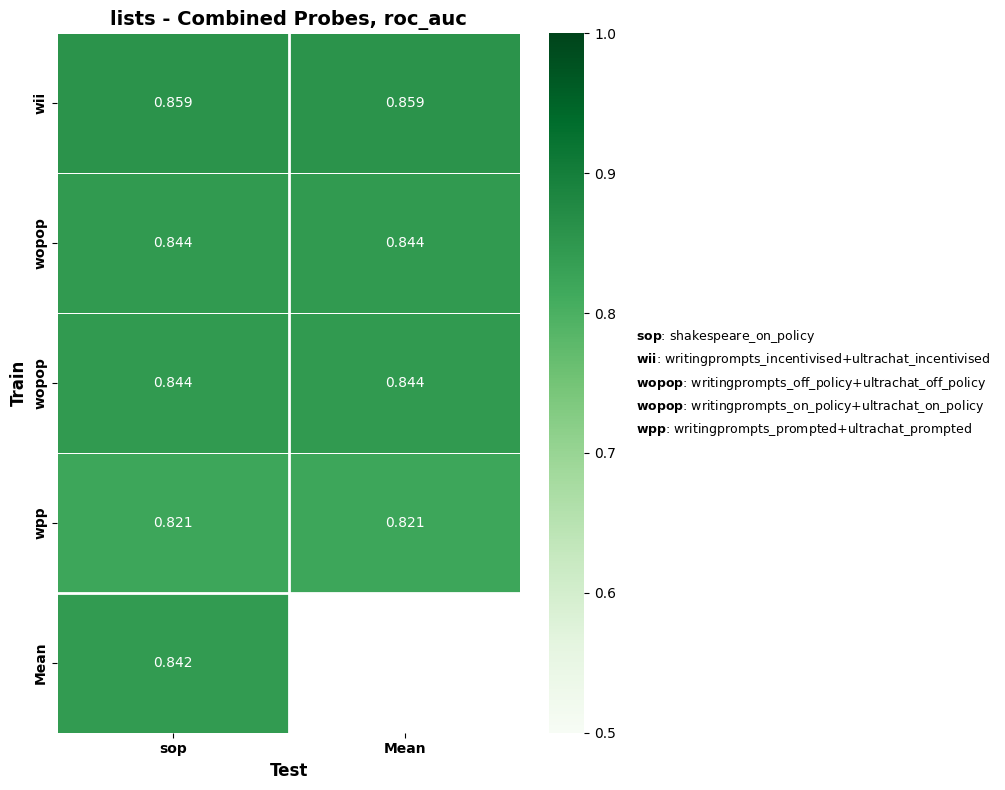

In [53]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

def plot_combined_probe_results(results_dir="combined_probe_results", metric="roc_auc", save=False, min_metric=0.5, max_metric=1):
    """
    Plot results from locally saved JSON files.
    
    Args:
        results_dir: Directory containing the JSON result files
        metric: Metric to plot ("roc_auc", "accuracy", "tpr_at_1_fpr")
        save: Whether to save the figure
        min_metric: Minimum value for colorbar
        max_metric: Maximum value for colorbar
    """
    results_dir = Path(results_dir)
    
    # Load all JSON files
    json_files = list(results_dir.glob("*.json"))
    
    if not json_files:
        print(f"No JSON files found in {results_dir}")
        return
    
    print(f"Found {len(json_files)} result files")
    
    # Parse results into a structured format
    results_data = []
    for json_file in json_files:
        with open(json_file, 'r') as f:
            data = json.load(f)
            results_data.append(data)
    
    # Extract unique train and test configurations
    train_configs = []
    test_configs = []
    
    for data in results_data:
        train_name = data['train_set']['combined_name']
        test_name = f"{data['test_set']['datasource']}_{data['test_set']['generation_method']}"
        
        if train_name not in train_configs:
            train_configs.append(train_name)
        if test_name not in test_configs:
            test_configs.append(test_name)
    
    # Sort for consistency
    train_configs.sort()
    test_configs.sort()
    
    print(f"\nTrain configurations: {train_configs}")
    print(f"Test configurations: {test_configs}")
    
    # Create results table
    n_train = len(train_configs)
    n_test = len(test_configs)
    results_table = np.full((n_train, n_test), np.nan)
    
    # Fill in the results
    for data in results_data:
        train_name = data['train_set']['combined_name']
        test_name = f"{data['test_set']['datasource']}_{data['test_set']['generation_method']}"
        
        train_idx = train_configs.index(train_name)
        test_idx = test_configs.index(test_name)
        
        metric_value = data['results'].get(metric, np.nan)
        results_table[train_idx, test_idx] = metric_value
    
    print(f"\nResults table shape: {results_table.shape}")
    print(f"Results table:\n{results_table}")
    
    # Create abbreviated labels
    def abridge(label):
        return "".join([p[0] for p in label.split("_") if p])
    
    train_short_labels = [abridge(lbl) for lbl in train_configs]
    test_short_labels = [abridge(lbl) for lbl in test_configs]
    
    # Add means
    row_means = np.nanmean(results_table, axis=1, keepdims=True)
    col_means = np.nanmean(results_table, axis=0, keepdims=True)
    full_table = np.block([
        [results_table, row_means],
        [col_means, np.array([[np.nan]])],
    ])
    
    mask = np.isnan(full_table)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Set color scale
    valid_values = results_table[~np.isnan(results_table)]
    vmin = min_metric if min_metric is not None else (np.min(valid_values) if valid_values.size > 0 else 0)
    vmax = max_metric if max_metric is not None else (np.max(valid_values) if valid_values.size > 0 else 1)
    
    sns.heatmap(
        full_table,
        mask=mask,
        annot=True,
        fmt=".3f",
        cmap="Greens",
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        ax=ax,
        linewidths=0.5,
        linecolor='white',
        annot_kws={"size": 10},
        xticklabels=test_short_labels + ["Mean"],
        yticklabels=train_short_labels + ["Mean"],
    )
    
    # Bold labels
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")
    
    # Add separator lines
    n_rows, n_cols = results_table.shape
    ax.axhline(n_rows, color='white', linewidth=2)
    ax.axvline(n_cols, color='white', linewidth=2)
    
    # Create legend
    legend_elements = []
    for short, full in zip(test_short_labels, test_configs):
        legend_elements.append(Patch(facecolor='none', edgecolor='none', label=rf"$\mathbf{{{short}}}$: {full}"))
    for short, full in zip(train_short_labels, train_configs):
        legend_elements.append(Patch(facecolor='none', edgecolor='none', label=rf"$\mathbf{{{short}}}$: {full}"))
    
    ax.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1.15, 0.5),
        title="",
        frameon=False,
        fontsize=9
    )
    
    # Get behaviour from first result
    behaviour = results_data[0]['behaviour']
    
    ax.set_xlabel("Test", fontsize=12, fontweight="bold")
    ax.set_ylabel("Train", fontsize=12, fontweight="bold")
    ax.set_title(f"{behaviour} - Combined Probes, {metric}", fontsize=14, fontweight="bold")
    
    fig.tight_layout()
    
    if save:
        save_path = results_dir / f"combined_probes_{behaviour}_{metric}_heatmap.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Saved figure to {save_path}")
    
    plt.show()
    
    return results_table, train_configs, test_configs


def print_results_summary(results_dir="combined_probe_results"):
    """Print a detailed summary of all results."""
    results_dir = Path(results_dir)
    json_files = list(results_dir.glob("*.json"))
    
    if not json_files:
        print(f"No JSON files found in {results_dir}")
        return
    
    print("="*80)
    print("COMBINED PROBE RESULTS SUMMARY")
    print("="*80)
    
    results_by_train = {}
    
    for json_file in json_files:
        with open(json_file, 'r') as f:
            data = json.load(f)
        
        train_name = data['train_set']['combined_name']
        test_name = f"{data['test_set']['datasource']} + {data['test_set']['generation_method']}"
        
        if train_name not in results_by_train:
            results_by_train[train_name] = []
        
        results_by_train[train_name].append({
            'test': test_name,
            'results': data['results'],
            'train_size': data['train_size'],
            'val_size': data['val_size']
        })
    
    for train_name, test_results in sorted(results_by_train.items()):
        print(f"\n{train_name}")
        print("-" * 80)
        
        if test_results:
            print(f"Training set size: {test_results[0]['train_size']} (val: {test_results[0]['val_size']})")
        
        for test_info in test_results:
            print(f"\n  Test: {test_info['test']}")
            results = test_info['results']
            print(f"    Accuracy:     {results['accuracy']:.4f}")
            print(f"    ROC AUC:      {results['roc_auc']:.4f}")
            print(f"    TPR@1%FPR:    {results['tpr_at_1_fpr']:.4f}")


# Usage:
print_results_summary()

# Plot with ROC AUC
results_table, train_configs, test_configs = plot_combined_probe_results(
    metric="roc_auc",
    save=True,
    min_metric=0.5,
    max_metric=1.0
)

# You can also plot other metrics
# plot_combined_probe_results(metric="accuracy", save=True)
# plot_combined_probe_results(metric="tpr_at_1_fpr", save=True, min_metric=0.0, max_metric=0.5)

Found 4 result files

✓ Saved figure to combined_probe_results/combined_probes_lists_auroc_simple.png


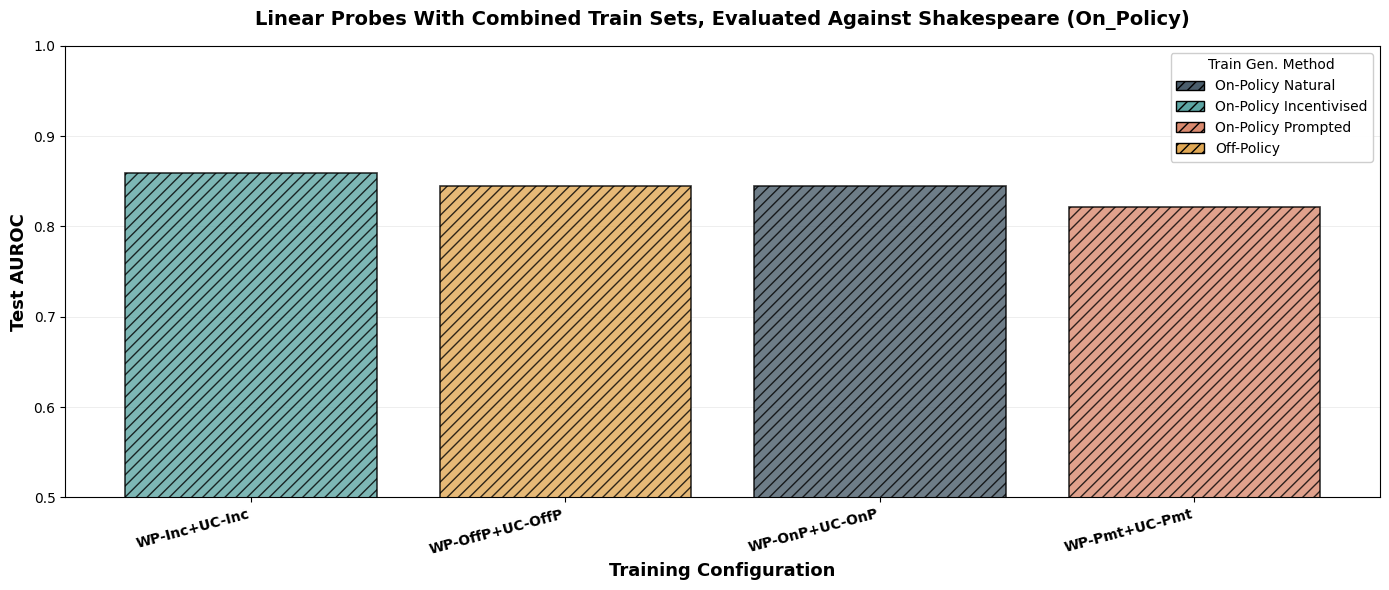


AUROC VALUES
WP-Inc+UC-Inc                 : 0.8590  (from: writingprompts_incentivised+ultrachat_incentivised)
WP-OffP+UC-OffP               : 0.8443  (from: writingprompts_off_policy+ultrachat_off_policy)
WP-OnP+UC-OnP                 : 0.8443  (from: writingprompts_on_policy+ultrachat_on_policy)
WP-Pmt+UC-Pmt                 : 0.8210  (from: writingprompts_prompted+ultrachat_prompted)


In [56]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_combined_probe_auroc_simple(results_dir="combined_probe_results", save=False):
    """
    Plot test AUROC results as a simple bar chart, similar to the reference style.
    
    Args:
        results_dir: Directory containing the JSON result files
        save: Whether to save the figure
    """
    results_dir = Path(results_dir)
    
    # Load all JSON files
    json_files = list(results_dir.glob("*.json"))
    
    if not json_files:
        print(f"No JSON files found in {results_dir}")
        return
    
    print(f"Found {len(json_files)} result files")
    
    # Parse results
    results_data = []
    for json_file in json_files:
        with open(json_file, 'r') as f:
            data = json.load(f)
            results_data.append(data)
    
    # Create better labels
    def create_label(combined_name):
        """Create readable labels for training configurations."""
        print(f"Processing: {combined_name}")  # Debug
        
        abbrev_map = {
            'writingprompts': 'WP',
            'ultrachat': 'UC',
            'on_policy': 'OnP',
            'off_policy': 'OffP',
            'incentivised': 'Inc',
            'prompted': 'Pmt'
        }
        
        # Split by + to get each dataset+method combination
        parts = combined_name.split('+')
        labeled = []
        
        for part in parts:
            # Split by underscore to get components
            components = part.split('_')
            
            # Identify dataset and method
            dataset = None
            method = None
            
            for comp in components:
                if comp in ['writingprompts', 'ultrachat']:
                    dataset = abbrev_map[comp]
                elif comp in ['on_policy', 'off_policy', 'incentivised', 'prompted']:
                    # Handle multi-word methods
                    if comp == 'on' and len(components) > components.index(comp) + 1:
                        if components[components.index(comp) + 1] == 'policy':
                            method = abbrev_map['on_policy']
                    elif comp == 'off' and len(components) > components.index(comp) + 1:
                        if components[components.index(comp) + 1] == 'policy':
                            method = abbrev_map['off_policy']
                    elif comp in ['incentivised', 'prompted']:
                        method = abbrev_map[comp]
            
            # Build label for this part
            if dataset and method:
                labeled.append(f"{dataset}-{method}")
            elif dataset:
                labeled.append(dataset)
        
        result = '+'.join(labeled)
        print(f"  -> {result}")  # Debug
        return result
    
    # Alternative simpler approach - use the full name directly
    def create_label_simple(combined_name):
        """Simplified label creation."""
        # Replace underscores and use standard abbreviations
        label = combined_name.replace('writingprompts', 'WP')
        label = label.replace('ultrachat', 'UC')
        label = label.replace('on_policy', 'OnP')
        label = label.replace('off_policy', 'OffP')
        label = label.replace('incentivised', 'Inc')
        label = label.replace('prompted', 'Pmt')
        # Remove any remaining underscores
        label = label.replace('_', '-')
        return label
    
    # Extract data
    train_configs = []
    auroc_values = []
    full_names = []
    behaviour = None
    test_config = None
    
    for data in results_data:
        train_name = data['train_set']['combined_name']
        train_label = create_label_simple(train_name)  # Use simpler version
        auroc = data['results']['roc_auc']
        
        train_configs.append(train_label)
        auroc_values.append(auroc)
        full_names.append(train_name)
        
        if behaviour is None:
            behaviour = data['behaviour']
        if test_config is None:
            test_name = data['test_set']['datasource']
            test_gen = data['test_set']['generation_method']
            test_config = f"{test_name} ({test_gen})"
    
    # Sort by label for consistent ordering
    sorted_data = sorted(zip(train_configs, auroc_values, full_names))
    train_configs = [x[0] for x in sorted_data]
    auroc_values = [x[1] for x in sorted_data]
    full_names = [x[2] for x in sorted_data]
    
    # Create colors based on generation method
    colors = []
    color_map = {
        'OnP': '#4a5d6b',  # Dark blue-gray (On-Policy Natural)
        'Inc': '#5da5a3',  # Teal (Incentivised)
        'Pmt': '#d98a6f',  # Orange-red (Prompted)
        'OffP': '#e0a855'  # Orange (Off-Policy)
    }
    
    for config in train_configs:
        if 'OnP' in config:
            colors.append(color_map['OnP'])
        elif 'Inc' in config:
            colors.append(color_map['Inc'])
        elif 'Pmt' in config:
            colors.append(color_map['Pmt'])
        elif 'OffP' in config:
            colors.append(color_map['OffP'])
        else:
            colors.append('#7f8c8d')  # Default gray
    
    # Create bar chart
    fig, ax = plt.subplots(figsize=(14, 6))
    
    x = np.arange(len(train_configs))
    bars = ax.bar(x, auroc_values, color=colors, edgecolor='black', linewidth=1.2, 
                   alpha=0.8, hatch='///')
    
    # Customize plot
    ax.set_xlabel('Training Configuration', fontsize=13, fontweight='bold')
    ax.set_ylabel('Test AUROC', fontsize=13, fontweight='bold')
    ax.set_title(f'Linear Probes With Combined Train Sets, Evaluated Against {test_config.title()}',
                 fontsize=14, fontweight='bold', pad=15)
    
    ax.set_xticks(x)
    ax.set_xticklabels(train_configs, rotation=15, ha='right', fontsize=10, fontweight='bold')
    
    # Set y-axis limits
    ax.set_ylim([0.5, 1.0])
    ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Create legend showing generation methods
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=color_map['OnP'], edgecolor='black', label='On-Policy Natural', hatch='///'),
        Patch(facecolor=color_map['Inc'], edgecolor='black', label='On-Policy Incentivised', hatch='///'),
        Patch(facecolor=color_map['Pmt'], edgecolor='black', label='On-Policy Prompted', hatch='///'),
        Patch(facecolor=color_map['OffP'], edgecolor='black', label='Off-Policy', hatch='///')
    ]
    ax.legend(handles=legend_elements, title='Train Gen. Method', 
             loc='upper right', framealpha=0.95, fontsize=10)
    
    plt.tight_layout()
    
    if save:
        save_path = results_dir / f"combined_probes_{behaviour}_auroc_simple.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Saved figure to {save_path}")
    
    plt.show()
    
    # Print values with full names
    print("\n" + "="*80)
    print("AUROC VALUES")
    print("="*80)
    for config, auroc, full in zip(train_configs, auroc_values, full_names):
        print(f"{config:30s}: {auroc:.4f}  (from: {full})")


# Usage:
plot_combined_probe_auroc_simple(save=True)